# Assignment 2: Volatility, Econometrics for Quantitative Finance (group 1)

Reads the LSE price file `etf_full-L.csv` (same folder), computes the returns of CSPX.L and VUAG.L, estimates all models and writes every table (LaTeX) and figure (PDF) of the report to `output/`. Run all cells from top to bottom (about 15 seconds).

In [1]:
import itertools
import os

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from scipy.optimize import minimize
from scipy.signal import lfilter, lfiltic
from scipy.special import gammaln
from statsmodels.stats.diagnostic import acorr_ljungbox

OUT = "output"
RAW = "etf_full-L.csv"
TICKERS = ["CSPX.L", "VUAG.L"]
LIBERATION_DAY = pd.Timestamp("2025-04-02")
GRID_P, GRID_Q, GRID_O = (0, 1, 2, 3), (1, 2, 3), (0, 1, 2)
OOS_START = pd.Timestamp("2025-01-01")  # forecast evaluation: estimate on 2021-2024, forecast 2025
BASE_MODELS = ["GARCH", "EWMA", "RiskMetrics"]
COLORS = {"GARCH": "#1f77b4", "EWMA": "#2ca02c", "RiskMetrics": "#ff7f0e", "GJR": "#d62728", "GJR-t": "#8c564b"}
plt.rcParams.update({"font.size": 9, "axes.titlesize": 9, "legend.fontsize": 7.5})

## Univariate models

In [2]:
# All models are special cases of the GJR(p, q, o) model of the assignment,
#     y_t ~ N(mu, s2_t) (or a standardised Student-t with nu degrees of freedom),   u_t = y_t - mu,
#     s2_{t+1} = omega + sum_j alpha_j u_{t-j+1}^2 + sum_i delta_i s2_{t-i+1}
#                      + sum_k gamma_k u_{t-k+1}^2 I(u_{t-k+1} < 0).
# The recursion starts at s2_1 = mean(u^2); pre-sample u^2 and s2 are set to the same value, and
# pre-sample u^2 I(u < 0) to half of it. For forecasting, s2_0 is passed in from the estimation sample.

def variance_filter(y, mu, omega, alpha, delta, gamma, s2_0=None):
    """Conditional variances s2_1..s2_T of the GJR recursion."""
    u = y - mu
    T = len(u)
    if s2_0 is None:
        s2_0 = u @ u / T
    m = max(len(alpha), len(delta), len(gamma), 1)
    u2 = np.r_[np.full(m - 1, s2_0), u**2]
    u2neg = np.r_[np.full(m - 1, s2_0 / 2), u**2 * (u < 0)]
    # c[t] = omega + ARCH and asymmetry terms entering s2_{t+1}, t = 1..T-1
    c = np.full(T - 1, omega)
    if len(alpha):
        c += np.convolve(u2, alpha)[m - 1:m - 1 + T - 1]
    if len(gamma):
        c += np.convolve(u2neg, gamma)[m - 1:m - 1 + T - 1]
    # s2_{t+1} = c[t] + sum_i delta_i s2_{t-i+1}: a linear recursive filter in s2
    a = np.r_[1.0, -np.asarray(delta)]
    zi = lfiltic([1.0], a, np.full(len(delta), s2_0)) if len(delta) else None
    s2 = lfilter([1.0], a, c, zi=zi)[0] if len(delta) else c
    return np.r_[s2_0, s2]

In [3]:
def loglik_obs(y, s2, mu, nu=None):
    """Log-density of y_t given s2_t: normal, or Student-t scaled to variance s2_t if nu is given."""
    if nu is None:
        return -0.5 * (np.log(2 * np.pi) + np.log(s2) + (y - mu) ** 2 / s2)
    return (gammaln((nu + 1) / 2) - gammaln(nu / 2) - 0.5 * np.log(np.pi * (nu - 2)) - 0.5 * np.log(s2)
            - (nu + 1) / 2 * np.log1p((y - mu) ** 2 / ((nu - 2) * s2)))

In [4]:
class Model:
    """A volatility model: maps free parameters theta to (mu, omega, alpha, delta, gamma).

    With dist="t" the last element of theta is the degrees of freedom nu of the Student-t."""

    def __init__(self, name, p=1, q=1, o=0, dist="normal"):
        self.name, self.p, self.q, self.o, self.dist = name, p, q, o, dist

    @property
    def labels(self):
        if self.name == "EWMA":
            return [r"\mu", r"\delta_1"]
        if self.name == "RiskMetrics":
            return [r"\mu"]
        lab = [r"\mu", r"\omega"]
        lab += [rf"\alpha_{j}" for j in range(1, self.q + 1)]
        lab += [rf"\delta_{i}" for i in range(1, self.p + 1)]
        lab += [rf"\gamma_{k}" for k in range(1, self.o + 1)]
        return lab + [r"\nu"] if self.dist == "t" else lab

    def unpack(self, theta):
        if self.name == "EWMA":
            mu, d = theta
            return mu, 0.0, np.array([1 - d]), np.array([d]), np.array([])
        if self.name == "RiskMetrics":
            return theta[0], 0.0, np.array([0.06]), np.array([0.94]), np.array([])
        p, q, o = self.p, self.q, self.o
        return theta[0], theta[1], theta[2:2 + q], theta[2 + q:2 + q + p], theta[2 + q + p:2 + q + p + o]

    def nu(self, theta):
        return theta[-1] if self.dist == "t" else None

    def variance(self, theta, y, s2_0=None):
        return variance_filter(y, *self.unpack(theta), s2_0=s2_0)

    def loglik_obs(self, theta, y, s2=None):
        s2 = self.variance(theta, y) if s2 is None else s2
        return loglik_obs(y, s2, theta[0], self.nu(theta))

    def pit(self, theta, v):
        """q_t: the model cdf evaluated at the standardised residual v_t."""
        nu = self.nu(theta)
        return stats.norm.cdf(v) if nu is None else stats.t.cdf(v * np.sqrt(nu / (nu - 2)), nu)

In [5]:
def fit(model, y, starts=()):
    """Maximum likelihood with standard (inverse Hessian) and robust (sandwich) standard errors."""
    if model.name == "RiskMetrics":
        theta = np.array([y.mean()])  # mu is fixed at the sample mean, nothing to optimise
    else:
        theta = _optimise(model, y, starts)
    ll = model.loglik_obs(theta, y).sum()
    k, T = len(theta), len(y)
    se, se_rob = _standard_errors(model, theta, y)
    if model.name == "RiskMetrics":
        se = se_rob = np.array([y.std(ddof=1) / np.sqrt(T)])
    s2 = model.variance(theta, y)
    return {
        "model": model, "theta": theta, "se": se, "se_rob": se_rob, "loglik": ll, "k": k,
        "aic": -2 * ll + 2 * k, "bic": -2 * ll + k * np.log(T),
        "s2": s2, "v": (y - theta[0]) / np.sqrt(s2), "q": model.pit(theta, (y - theta[0]) / np.sqrt(s2)),
    }

In [6]:
def _optimise(model, y, starts):
    var = y.var()
    if model.name == "EWMA":
        bounds = [(-1, 1), (0.5, 0.9999)]
        cons = []
        starts = list(starts) + [np.array([y.mean(), 0.94]), np.array([y.mean(), 0.97])]
    else:
        p, q, o = model.p, model.q, model.o
        bounds = [(-1, 1), (1e-6, 10 * var)] + [(0, 1)] * q + [(0, 1)] * p + [(-1, 1)] * o
        alpha = lambda th: th[2:2 + q]
        delta = lambda th: th[2 + q:2 + q + p]
        gamma = lambda th: th[2 + q + p:2 + q + p + o]
        cons = [
            # covariance stationarity (approximately, for symmetric shocks)
            {"type": "ineq", "fun": lambda th: 0.9999 - alpha(th).sum() - delta(th).sum() - 0.5 * gamma(th).sum()},
            # positive variance: the news impact of a negative shock at each lag must be >= 0
            {"type": "ineq", "fun": lambda th: np.r_[alpha(th), np.zeros(max(o - q, 0))][:o] + gamma(th)
             if o else np.array([1.0])},
        ]
        default = []
        for a0, d0, g0 in [(0.05, 0.90, 0.05), (0.02, 0.85, 0.15), (0.10, 0.80, 0.0)]:
            a = np.full(q, a0 / q)
            d = np.full(p, d0 / p) if p else np.array([])
            g = np.full(o, g0 / o) if o else np.array([])
            pers = a.sum() + d.sum() + g.sum() / 2
            default.append(np.r_[y.mean(), var * (1 - pers), a, d, g])
        if model.dist == "t":
            bounds.append((2.05, 200))
            default = [np.r_[x0, nu0] for x0 in default for nu0 in (5.0, 10.0)]
        starts = list(starts) + default

    def nll(theta):
        try:
            ll = model.loglik_obs(theta, y).sum()
        except FloatingPointError:
            return 1e10
        return -ll if np.isfinite(ll) else 1e10

    best = None
    for x0 in starts:
        x0 = np.clip(x0, [b[0] for b in bounds], [b[1] for b in bounds])
        res = minimize(nll, x0, method="SLSQP", bounds=bounds, constraints=cons,
                       options={"maxiter": 1000, "ftol": 1e-10})
        if best is None or res.fun < best.fun:
            best = res
    return best.x

In [7]:
def _num_grad(f, theta, h):
    """Central-difference Jacobian of a (vector valued) function, columns per parameter."""
    cols = []
    for i in range(len(theta)):
        e = np.zeros_like(theta)
        e[i] = h[i]
        cols.append((f(theta + e) - f(theta - e)) / (2 * h[i]))
    return np.column_stack(cols)

In [8]:
def _standard_errors(model, theta, y):
    h = 1e-4 * np.maximum(np.abs(theta), 1e-2)
    scores = _num_grad(lambda th: model.loglik_obs(th, y), theta, h)  # T x k
    hess = _num_grad(lambda th: _num_grad(lambda t2: model.loglik_obs(t2, y).sum(), th, h).ravel(), theta, h)
    hess = (hess + hess.T) / 2
    with np.errstate(invalid="ignore"):
        try:
            hinv = np.linalg.inv(-hess)
            se = np.sqrt(np.diag(hinv))
            se_rob = np.sqrt(np.diag(hinv @ (scores.T @ scores) @ hinv))
        except np.linalg.LinAlgError:
            se = se_rob = np.full(len(theta), np.nan)
    return se, se_rob

In [9]:
def fit_gjr_grid(y):
    """All GJR(p, q, o) for the grid of the assignment, warm-started from the nested models."""
    fits = {}
    for p, q, o in sorted(itertools.product(GRID_P, GRID_Q, GRID_O), key=sum):
        model = Model("GJR", p, q, o)
        starts = []
        for (pp, qq, oo), f in fits.items():
            if pp <= p and qq <= q and oo <= o and (p - pp) + (q - qq) + (o - oo) == 1:
                m0 = f["model"]
                mu, om, a, d, g = m0.unpack(f["theta"])
                starts.append(np.r_[mu, om, np.r_[a, np.zeros(q - qq)], np.r_[d, np.zeros(p - pp)],
                                    np.r_[g, np.zeros(o - oo)]])
        fits[(p, q, o)] = fit(model, y, starts)
    return fits

## DCC (correlation part)

In [10]:
def dcc_filter(a, b, V):
    """Correlations rho_t, t = 1..T, from Q_{t+1} = (1-a-b) S + a v_t v_t' + b Q_t, Q_1 = S.

    rho_t depends on v_1..v_{t-1} only, so v_t can be scored under R_t."""
    S = np.cov(V, rowvar=False)
    T = len(V)
    q11, q22, q12 = np.empty(T), np.empty(T), np.empty(T)
    q11[0], q22[0], q12[0] = S[0, 0], S[1, 1], S[0, 1]
    c = 1 - a - b
    for t in range(T - 1):
        q11[t + 1] = c * S[0, 0] + a * V[t, 0] ** 2 + b * q11[t]
        q22[t + 1] = c * S[1, 1] + a * V[t, 1] ** 2 + b * q22[t]
        q12[t + 1] = c * S[0, 1] + a * V[t, 0] * V[t, 1] + b * q12[t]
    return q12 / np.sqrt(q11 * q22)

In [11]:
def dcc_loglik_obs(params, V):
    """Log-density of v_t ~ N(0, R_t) for a bivariate v_t; params is (a, b) or a path rho_1..rho_T."""
    rho = dcc_filter(*params, V) if len(params) == 2 else params
    v1, v2 = V[:, 0], V[:, 1]
    det = 1 - rho**2
    return -np.log(2 * np.pi) - 0.5 * np.log(det) - 0.5 * (v1**2 + v2**2 - 2 * rho * v1 * v2) / det

In [12]:
def fit_dcc(V):
    nll = lambda th: -dcc_loglik_obs(th, V).sum()
    cons = [{"type": "ineq", "fun": lambda th: 0.9999 - th[0] - th[1]}]
    best = None
    for x0 in [(0.02, 0.95), (0.05, 0.90), (0.10, 0.80), (0.20, 0.60)]:
        res = minimize(nll, x0, method="SLSQP", bounds=[(0, 1), (0, 1)], constraints=cons,
                       options={"ftol": 1e-12, "maxiter": 1000})
        if best is None or res.fun < best.fun:
            best = res
    theta = best.x
    h = np.full(2, 1e-5)
    scores = _num_grad(lambda th: dcc_loglik_obs(th, V), theta, h)
    hess = _num_grad(lambda th: _num_grad(lambda t2: dcc_loglik_obs(t2, V).sum(), th, h).ravel(), theta, h)
    hinv = np.linalg.inv(-(hess + hess.T) / 2)
    se = np.sqrt(np.diag(hinv))
    se_rob = np.sqrt(np.diag(hinv @ (scores.T @ scores) @ hinv))
    rho_const = np.corrcoef(V, rowvar=False)[0, 1]
    ll_const = dcc_loglik_obs(np.full(len(V), rho_const), V).sum()
    return {"theta": theta, "se": se, "se_rob": se_rob, "loglik": -best.fun, "ll_const": ll_const,
            "rho_const": rho_const, "rho": dcc_filter(*theta, V)}

## Output helpers

In [13]:
def fmt(x, d=3):
    if x is None or not np.isfinite(x):
        return "--"
    s = f"{x:.{d}f}"
    return s.replace("-", "$-$") if s.startswith("-") else s

In [14]:
def fmt_p(p):
    return "$<$0.001" if p < 0.001 else f"{p:.3f}"

In [15]:
def write(name, text):
    with open(os.path.join(OUT, name), "w") as f:
        f.write(text)

In [16]:
def gjr_name(key):
    return "GJR({},{},{})".format(*key)

In [17]:
def fit_gjr_t(y, key, gjr_normal):
    """GJR with Student-t errors, started from the Gaussian estimates of the same order."""
    return fit(Model("GJR", *key, dist="t"), y, [np.r_[gjr_normal["theta"], nu0] for nu0 in (5.0, 8.0)])

In [18]:
def diebold_mariano(d, lags=5):
    """Two-sided p-value of H0: E[d_t] = 0, with a Newey-West long-run variance."""
    n = len(d)
    e = d - d.mean()
    lrv = e @ e / n
    for l in range(1, lags + 1):
        lrv += 2 * (1 - l / (lags + 1)) * (e[l:] @ e[:-l]) / n
    stat = d.mean() / np.sqrt(lrv / n)
    return stat, 2 * stats.norm.sf(abs(stat))

## Analysis

In [19]:
os.makedirs(OUT, exist_ok=True)
np.seterr(over="raise", invalid="ignore", divide="ignore")

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

### Data: daily log-returns in %

In [20]:
prices = pd.read_csv(RAW, parse_dates=["Date"], index_col="Date", usecols=["Date"] + TICKERS)
prices = prices.loc["2021-01-01":"2025-12-31"]
# The rows with missing prices are UK bank holidays (the exchange was closed), so we drop them;
# the return after a holiday then covers the closed day as well.
n_raw = len(prices)
prices = prices.dropna()
print(f"dropped {n_raw - len(prices)} non-trading rows, {len(prices)} trading days remain")
returns = 100 * np.log(prices / prices.shift(1)).dropna()
assets = list(returns.columns)
dates = returns.index
T = len(returns)
print(f"{T} returns for {assets}, {dates[0].date()} to {dates[-1].date()}")

dropped 31 non-trading rows, 1259 trading days remain
1258 returns for ['CSPX.L', 'VUAG.L'], 2021-01-05 to 2025-12-30


### Descriptives

In [21]:
rows = []
for a in assets:
    y = returns[a].values
    jb = stats.jarque_bera(y)
    lb = acorr_ljungbox(y**2, lags=[10])["lb_pvalue"].iloc[0]
    rows.append([a, y.mean(), y.std(ddof=1), y.std(ddof=1) * np.sqrt(252), stats.skew(y),
                 stats.kurtosis(y), y.min(), y.max(), jb.pvalue, lb])
corr = returns.corr().iloc[0, 1]
lines = [r"\begin{tabular}{lrrrrrrrrr}", r"\toprule",
         r" & Mean & Std.\ dev. & Ann.\ vol. & Skewness & Exc.\ kurt. & Min & Max & JB $p$ & LB$_{10}(y^2)$ $p$ \\",
         r"\midrule"]
for r in rows:
    lines.append(f"{r[0]} & " + " & ".join(
        [fmt(r[1]), fmt(r[2]), fmt(r[3], 1), fmt(r[4], 2), fmt(r[5], 2), fmt(r[6], 2), fmt(r[7], 2),
         fmt_p(r[8]), fmt_p(r[9])]) + r" \\")
lines += [r"\bottomrule", r"\end{tabular}"]
write("tab_desc.tex", "\n".join(lines))
print(f"return correlation {corr:.4f}")

return correlation 0.8487


### Estimation

In [22]:
results = {}
for a in assets:
    y = returns[a].values
    print(f"\n== {a}")
    grid = fit_gjr_grid(y)
    base = {
        "GARCH": grid[(1, 1, 0)],  # GARCH(1,1) is GJR(1,1,0)
        "EWMA": fit(Model("EWMA"), y),
        "RiskMetrics": fit(Model("RiskMetrics"), y),
    }
    base["GARCH"] = dict(base["GARCH"], model=Model("GARCH", 1, 1, 0))
    best_bic = min(grid, key=lambda k: grid[k]["bic"])
    best_aic = min(grid, key=lambda k: grid[k]["aic"])
    print(f"best BIC {gjr_name(best_bic)}, best AIC {gjr_name(best_aic)}")
    for key in sorted(grid):
        g = grid[key]
        print(f"  {gjr_name(key)}  ll={g['loglik']:.2f}  aic={g['aic']:.2f}  bic={g['bic']:.2f}  "
              f"theta={np.round(g['theta'], 4)}")
    gjr_t = fit_gjr_t(y, best_bic, grid[best_bic])
    print(f"{gjr_name(best_bic)}-t theta={np.round(gjr_t['theta'], 4)} ll={gjr_t['loglik']:.2f} "
          f"bic={gjr_t['bic']:.2f}")
    results[a] = {"grid": grid, "base": base, "best": best_bic, "best_aic": best_aic, "t": gjr_t}


== CSPX.L


best BIC GJR(1,1,1), best AIC GJR(2,1,1)
  GJR(0,1,0)  ll=-1740.93  aic=3487.86  bic=3503.27  theta=[0.0686 0.7179 0.3016]
  GJR(0,1,1)  ll=-1734.96  aic=3477.92  bic=3498.47  theta=[0.0481 0.7287 0.1325 0.3025]
  GJR(0,1,2)  ll=-1726.65  aic=3463.30  bic=3488.99  theta=[0.0471 0.6784 0.0707 0.3614 0.1811]
  GJR(0,2,0)  ll=-1726.02  aic=3460.04  bic=3480.59  theta=[0.0717 0.6081 0.2669 0.148 ]
  GJR(0,2,1)  ll=-1718.00  aic=3446.00  bic=3471.68  theta=[0.0555 0.6159 0.0697 0.1622 0.3337]
  GJR(0,2,2)  ll=-1716.71  aic=3445.41  bic=3476.24  theta=[0.0499 0.6095 0.0607 0.1177 0.3534 0.1183]
  GJR(0,3,0)  ll=-1710.03  aic=3430.05  bic=3455.74  theta=[0.0923 0.4984 0.2388 0.1377 0.1587]
  GJR(0,3,1)  ll=-1699.20  aic=3410.40  bic=3441.22  theta=[0.077  0.4992 0.0357 0.1449 0.1656 0.3533]
  GJR(0,3,2)  ll=-1698.32  aic=3410.64  bic=3446.60  theta=[0.0722 0.4942 0.0321 0.1067 0.1653 0.3659 0.0917]
  GJR(1,1,0)  ll=-1683.66  aic=3375.31  bic=3395.86  theta=[0.0878 0.047  0.127  0.8278]
  GJR(

best BIC GJR(1,1,1), best AIC GJR(3,1,2)
  GJR(0,1,0)  ll=-1652.22  aic=3310.43  bic=3325.84  theta=[0.0733 0.7042 0.1599]
  GJR(0,1,1)  ll=-1640.80  aic=3289.61  bic=3310.16  theta=[0.0538 0.687  0.0289 0.3186]
  GJR(0,1,2)  ll=-1632.34  aic=3274.67  bic=3300.36  theta=[0.0502 0.6428 0.     0.3161 0.1719]
  GJR(0,2,0)  ll=-1642.56  aic=3293.12  bic=3313.67  theta=[0.0672 0.6095 0.1292 0.1571]
  GJR(0,2,1)  ll=-1630.84  aic=3271.68  bic=3297.37  theta=[0.0527 0.5999 0.     0.1511 0.299 ]
  GJR(0,2,2)  ll=-1629.76  aic=3271.52  bic=3302.34  theta=[0.0482 0.603  0.     0.0925 0.3009 0.1092]
  GJR(0,3,0)  ll=-1632.72  aic=3275.44  bic=3301.12  theta=[0.0737 0.5257 0.1054 0.1727 0.1214]
  GJR(0,3,1)  ll=-1619.11  aic=3250.23  bic=3281.05  theta=[0.0616 0.5139 0.     0.1453 0.1204 0.2843]
  GJR(0,3,2)  ll=-1618.78  aic=3251.56  bic=3287.52  theta=[0.0591 0.5157 0.     0.1123 0.1186 0.285  0.0636]
  GJR(1,1,0)  ll=-1592.64  aic=3193.29  bic=3213.84  theta=[0.0866 0.0371 0.1003 0.8568]
  GJR(

### GJR grid table

In [23]:
lines = [r"\begin{tabular}{lr" + "rrr" * len(assets) + "}", r"\toprule",
         r" & & " + " & ".join(rf"\multicolumn{{3}}{{c}}{{{a}}}" for a in assets) + r" \\",
         "".join(rf"\cmidrule(lr){{{3 + 3 * i}-{5 + 3 * i}}}" for i in range(len(assets))),
         r"$(p,q,o)$ & $k$ & " + " & ".join([r"$\log L$ & AIC & BIC"] * len(assets)) + r" \\",
         r"\midrule"]
keys = sorted(results[assets[0]]["grid"], key=lambda k: (k[2], k[0], k[1]))
for i, key in enumerate(keys):
    if i and key[2] != keys[i - 1][2]:
        lines.append(r"\addlinespace")
    cells = []
    for a in assets:
        g = results[a]["grid"][key]
        aic = fmt(g["aic"], 1)
        bic = fmt(g["bic"], 1)
        if key == results[a]["best_aic"]:
            aic = rf"\textbf{{{aic}}}"
        if key == results[a]["best"]:
            bic = rf"\textbf{{{bic}}}"
        cells += [fmt(g["loglik"], 1), aic, bic]
    k = results[assets[0]]["grid"][key]["k"]
    lines.append(f"({key[0]},{key[1]},{key[2]}) & {k} & " + " & ".join(cells) + r" \\")
lines += [r"\bottomrule", r"\end{tabular}"]
write("tab_grid.tex", "\n".join(lines))

lines = [r"\begin{tabular}{l" + "lrrrr" * len(assets) + "}", r"\toprule",
         r" & " + " & ".join(rf"\multicolumn{{5}}{{c}}{{{a}}}" for a in assets) + r" \\",
         "".join(rf"\cmidrule(lr){{{2 + 5 * i}-{6 + 5 * i}}}" for i in range(len(assets))),
         "Rank & " + " & ".join([r"$(p,q,o)$ & $\log L$ & AIC & BIC & $\Delta$BIC"] * len(assets)) + r" \\",
         r"\midrule"]
ranked = {a: sorted(results[a]["grid"], key=lambda k: results[a]["grid"][k]["bic"]) for a in assets}
for i in range(5):
    cells = []
    for a in assets:
        key = ranked[a][i]
        g = results[a]["grid"][key]
        cells += [f"({key[0]},{key[1]},{key[2]})", fmt(g["loglik"], 1), fmt(g["aic"], 1), fmt(g["bic"], 1),
                  fmt(g["bic"] - results[a]["grid"][ranked[a][0]]["bic"], 1)]
    lines.append(f"{i + 1} & " + " & ".join(cells) + r" \\")
lines.append(r"\midrule")
cells = []
for a in assets:
    g = results[a]["grid"][(1, 1, 0)]
    cells += ["(1,1,0)", fmt(g["loglik"], 1), fmt(g["aic"], 1), fmt(g["bic"], 1),
              fmt(g["bic"] - results[a]["grid"][ranked[a][0]]["bic"], 1)]
lines.append("GARCH & " + " & ".join(cells) + r" \\")
lines += [r"\bottomrule", r"\end{tabular}"]
write("tab_grid_top.tex", "\n".join(lines))

### Parameter table (5 models per asset)

In [24]:
order = [r"\mu", r"\omega", r"\alpha_1", r"\alpha_2", r"\alpha_3", r"\delta_1", r"\delta_2", r"\delta_3",
         r"\gamma_1", r"\gamma_2", r"\nu"]
lines = []
for a in assets:
    r = results[a]
    models = {**r["base"], "GJR": r["grid"][r["best"]], "GJR-t": r["t"]}
    names = ["GARCH(1,1)", "EWMA", "RiskMetrics", gjr_name(r["best"]), gjr_name(r["best"]) + "-$t$"]
    used = [l for l in order if any(l in m["model"].labels for m in models.values())]
    lines += [rf"\multicolumn{{6}}{{l}}{{\textit{{{a}}}}} \\", r"\midrule" if a == assets[0] else "",
              " & " + " & ".join(names) + r" \\", r"\midrule"]
    for lab in used:
        est, ses = [], []
        for m in models.values():
            if lab in m["model"].labels:
                i = m["model"].labels.index(lab)
                d = 4 if lab == r"\omega" else 2 if lab == r"\nu" else 3
                est.append(fmt(m["theta"][i], d))
                ses.append("(" + fmt(m["se_rob"][i], d) + ")")
            elif lab == r"\alpha_1" and m["model"].name in ("EWMA", "RiskMetrics"):
                _, _, al, _, _ = m["model"].unpack(m["theta"])
                est.append(r"\textit{" + fmt(al[0]) + "}")
                ses.append("")
            elif lab == r"\delta_1" and m["model"].name == "RiskMetrics":
                est.append(r"\textit{0.940}")
                ses.append("")
            elif lab == r"\omega" and m["model"].name in ("EWMA", "RiskMetrics"):
                est.append(r"\textit{0}")
                ses.append("")
            else:
                est.append("")
                ses.append("")
        lines.append(f"${lab}$ & " + " & ".join(est) + r" \\")
        lines.append(" & " + " & ".join(ses) + r" \\[1pt]")
    pers = []
    for m in models.values():
        _, _, al, de, ga = m["model"].unpack(m["theta"])
        pers.append(fmt(al.sum() + de.sum() + ga.sum() / 2))
    lines += [r"\midrule", "Persistence & " + " & ".join(pers) + r" \\",
              "$k$ & " + " & ".join(str(m["k"]) for m in models.values()) + r" \\",
              r"$\log L$ & " + " & ".join(fmt(m["loglik"], 1) for m in models.values()) + r" \\",
              "AIC & " + " & ".join(fmt(m["aic"], 1) for m in models.values()) + r" \\",
              "BIC & " + " & ".join(fmt(m["bic"], 1) for m in models.values()) + r" \\"]
    if a != assets[-1]:
        lines += [r"\midrule\midrule"]
write("tab_params.tex", "\n".join([r"\begin{tabular}{lrrrrr}", r"\toprule"] + [l for l in lines if l]
                                  + [r"\bottomrule", r"\end{tabular}"]))

# LR tests of the restrictions in the base models and of the asymmetry
lr_lines = []
for a in assets:
    r = results[a]
    g, e, rm = r["base"]["GARCH"], r["base"]["EWMA"], r["base"]["RiskMetrics"]
    gj = r["grid"][r["best"]]
    tests = [("EWMA vs GARCH(1,1)", e, g), ("RiskMetrics vs EWMA", rm, e), ("GARCH(1,1) vs " + gjr_name(r["best"]), g, gj)]
    for label, small, big in tests:
        lr = 2 * (big["loglik"] - small["loglik"])
        df = big["k"] - small["k"]
        lr_lines.append((a, label, lr, df, stats.chi2.sf(lr, df)))
lines = [r"\begin{tabular}{llrrr}", r"\toprule", r" & Restricted vs unrestricted & LR & df & $p$ \\", r"\midrule"]
for i, (a, label, lr, df, p) in enumerate(lr_lines):
    lines.append(f"{a if i % 3 == 0 else ''} & {label} & {fmt(lr, 2)} & {df} & {fmt_p(p)}" + r" \\")
lines += [r"\bottomrule", r"\end{tabular}"]
write("tab_lr.tex", "\n".join(lines))

### Residual diagnostics

In [25]:
lines = [r"\begin{tabular}{llrrrrrrr}", r"\toprule",
         r" & Model & Std.\ dev.\ $v_t$ & Skew. & Exc.\ kurt. & JB $p$ & LB$_{10}(v^2)$ $p$ & KS $p$ & $\chi^2_{9}$ $p$ \\",
         r"\midrule"]
for a in assets:
    r = results[a]
    models = {**r["base"], "GJR": r["grid"][r["best"]], "GJR-t": r["t"]}
    for i, (name, m) in enumerate(models.items()):
        v = m["v"]
        qt = m["q"]
        counts = np.histogram(qt, bins=10, range=(0, 1))[0]
        chi = stats.chisquare(counts).pvalue
        label = {"GJR": gjr_name(r["best"]), "GJR-t": gjr_name(r["best"]) + "-$t$",
                 "GARCH": "GARCH(1,1)"}.get(name, name)
        lines.append(f"{a if i == 0 else ''} & {label} & {fmt(v.std(ddof=1))} & {fmt(stats.skew(v), 2)} & "
                     f"{fmt(stats.kurtosis(v), 2)} & {fmt_p(stats.jarque_bera(v).pvalue)} & "
                     f"{fmt_p(acorr_ljungbox(v**2, lags=[10])['lb_pvalue'].iloc[0])} & "
                     f"{fmt_p(stats.kstest(qt, 'uniform').pvalue)} & {fmt_p(chi)}" + r" \\")
    if a != assets[-1]:
        lines.append(r"\midrule")
lines += [r"\bottomrule", r"\end{tabular}"]
write("tab_diag.tex", "\n".join(lines))

### Figures: volatility

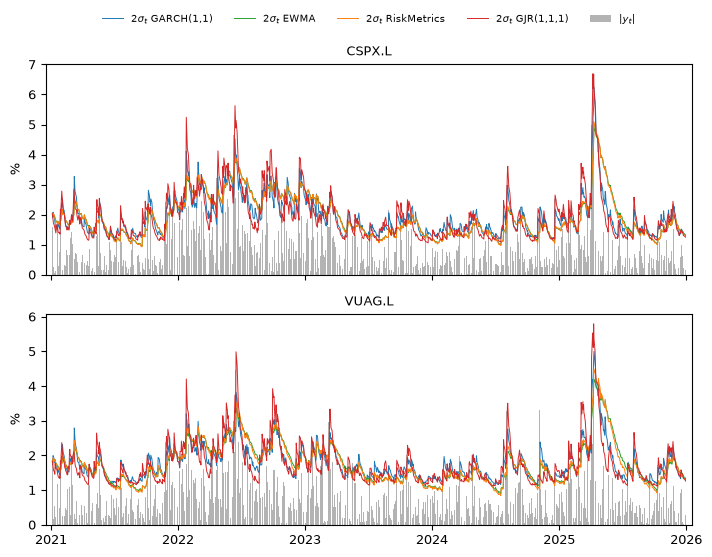

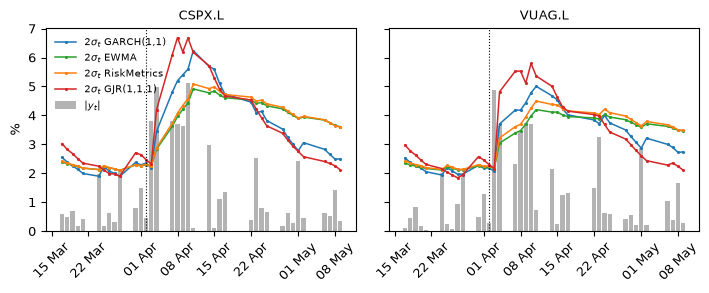


2*sigma_t around Liberation Day
CSPX.L
            GARCH(1,1)  EWMA  RiskMetrics  GJR(1,1,1)   |y|
Date                                                       
2025-03-31        2.38  2.29         2.30        2.71  0.79
2025-04-01        2.29  2.26         2.27        2.65  1.49
2025-04-02        2.35  2.29         2.31        2.47  0.46
2025-04-03        2.20  2.24         2.25        2.32  3.80
2025-04-04        3.45  2.83         2.88        4.20  4.98
2025-04-07        4.80  3.62         3.73        6.09  3.81
2025-04-08        5.20  3.96         4.08        6.69  3.70
2025-04-09        5.40  4.21         4.34        6.19  3.62
2025-04-10        5.60  4.44         4.58        6.67  5.11
2025-04-11        6.24  4.92         5.08        6.18  0.10
2025-04-14        5.69  4.78         4.93        5.72  2.98
2025-04-15        5.59  4.84         4.99        5.30  0.12
2025-04-16        5.11  4.71         4.84        4.91  1.11
2025-04-17        4.74  4.61         4.72        4.67  1.36


In [26]:
def model_set(a):
    r = results[a]
    return [("GARCH(1,1)", r["base"]["GARCH"], COLORS["GARCH"]), ("EWMA", r["base"]["EWMA"], COLORS["EWMA"]),
            ("RiskMetrics", r["base"]["RiskMetrics"], COLORS["RiskMetrics"]),
            (gjr_name(r["best"]), r["grid"][r["best"]], COLORS["GJR"])]

fig, axes = plt.subplots(2, 1, figsize=(7.2, 5.6), sharex=True)
for ax, a in zip(axes, assets):
    ax.bar(dates, np.abs(returns[a]), width=1.5, color="0.7", label="$|y_t|$")
    for label, m, col in model_set(a):
        ax.plot(dates, 2 * np.sqrt(m["s2"]), color=col, lw=0.7, label=rf"$2\sigma_t$ {label}")
    ax.set_title(a)
    ax.set_ylabel("%")
    ax.set_ylim(0, None)
    ax.margins(x=0.01)
axes[0].legend(ncol=5, loc="upper center", frameon=False, bbox_to_anchor=(0.5, 1.28))
fig.tight_layout()
fig.savefig(os.path.join(OUT, "fig_vol_full.pdf"))
plt.show()

window = (dates >= "2025-03-17") & (dates <= "2025-05-09")
fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.0), sharey=True)
for ax, a in zip(axes, assets):
    ax.bar(dates[window], np.abs(returns[a][window]), width=0.8, color="0.7", label="$|y_t|$")
    for label, m, col in model_set(a):
        ax.plot(dates[window], 2 * np.sqrt(m["s2"][window]), color=col, lw=1.1, marker=".", ms=2.5,
                label=rf"$2\sigma_t$ {label}")
    ax.axvline(LIBERATION_DAY, color="k", ls=":", lw=0.8)
    ax.set_title(a)
    ax.tick_params(axis="x", labelrotation=45)
    ax.xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%d %b"))
axes[0].set_ylabel("%")
axes[0].legend(loc="upper left", frameon=False)
fig.tight_layout()
fig.savefig(os.path.join(OUT, "fig_vol_liberation.pdf"))
plt.show()

# values around Liberation Day for the text
print("\n2*sigma_t around Liberation Day")
for a in assets:
    tab = pd.DataFrame({label: 2 * np.sqrt(m["s2"]) for label, m, _ in model_set(a)}, index=dates)
    tab["|y|"] = returns[a].abs()
    print(a)
    print(tab.loc["2025-03-31":"2025-04-25"].round(2).to_string())
    pre = tab.loc["2025-03-03":"2025-03-31"].mean()
    peak = tab.loc["2025-04-01":"2025-04-30"].max()
    print("March mean\n", pre.round(2).to_string(), "\nApril max\n", peak.round(2).to_string())

### Figure: q_t histograms

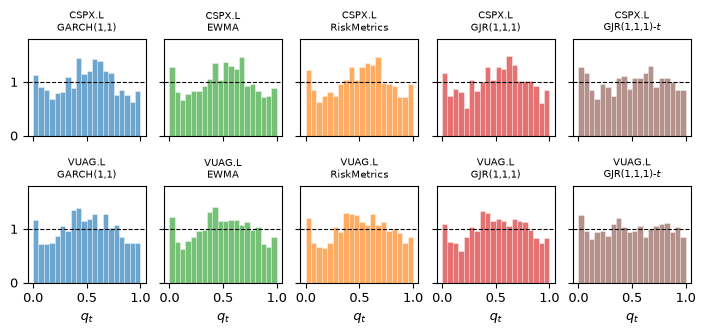

In [27]:
fig, axes = plt.subplots(2, 5, figsize=(7.2, 3.4), sharex=True, sharey=True)
for row, a in zip(axes, assets):
    r = results[a]
    for ax, (label, m, col) in zip(row, model_set(a) + [(gjr_name(r["best"]) + "-$t$", r["t"], COLORS["GJR-t"])]):
        ax.hist(m["q"], bins=20, range=(0, 1), density=True, color=col, alpha=0.65,
                edgecolor="white", lw=0.4)
        ax.axhline(1, color="k", ls="--", lw=0.8)
        ax.set_title(f"{a}\n{label}", fontsize=7)
        ax.set_ylim(0, 1.8)
for ax in axes[1]:
    ax.set_xlabel("$q_t$")
fig.tight_layout()
fig.savefig(os.path.join(OUT, "fig_qt.pdf"))
plt.show()

### Out-of-sample forecasts

In [28]:
# Every model (and the GJR order, by BIC) is estimated once on 2021-2024. With these parameters the
# recursion gives one-step-ahead variance forecasts s2_t for 2025 that use only y_1..y_{t-1}.
# Loss functions use y_t^2 as proxy for the unobserved variance.
in_s = np.asarray(dates < OOS_START)
T_out = int((~in_s).sum())
lines = [r"\begin{tabular}{llrrrrrr}", r"\toprule",
         r" & Model & QLIKE & DM $p$ & MSE & DM $p$ & Pred.\ $\log L$ & $|u_t|>2\sigma_t$ \\", r"\midrule"]
print(f"\nout-of-sample: {in_s.sum()} estimation days, {T_out} forecast days")
for ia, a in enumerate(assets):
    y = returns[a].values
    y_in, y_out = y[in_s], y[~in_s]
    grid_in = fit_gjr_grid(y_in)
    best_in = min(grid_in, key=lambda k: grid_in[k]["bic"])
    fits_in = {"GARCH(1,1)": dict(grid_in[(1, 1, 0)], model=Model("GARCH", 1, 1, 0)),
               "EWMA": fit(Model("EWMA"), y_in), "RiskMetrics": fit(Model("RiskMetrics"), y_in),
               gjr_name(best_in): grid_in[best_in],
               gjr_name(best_in) + "-$t$": fit_gjr_t(y_in, best_in, grid_in[best_in])}
    bench = gjr_name(best_in)
    print(f"{a}: BIC on 2021-2024 selects {bench}")
    loss = {}
    for name, f in fits_in.items():
        m, th = f["model"], f["theta"]
        u_in = y_in - th[0]
        s2 = m.variance(th, y, s2_0=u_in @ u_in / len(u_in))[~in_s]
        loss[name] = {"qlike": np.log(s2) + y_out**2 / s2, "mse": (y_out**2 - s2) ** 2,
                      "ll": m.loglik_obs(th, y_out, s2=s2),
                      "exc": np.mean(np.abs(y_out - th[0]) > 2 * np.sqrt(s2)), "theta": th}
    for i, (name, L) in enumerate(loss.items()):
        dm = {k: ("--" if name == bench else fmt_p(diebold_mariano(L[k] - loss[bench][k])[1]))
              for k in ("qlike", "mse")}
        stat_q = diebold_mariano(L["qlike"] - loss[bench]["qlike"])[0] if name != bench else 0
        print(f"  {name:20s} QLIKE={L['qlike'].mean():.4f} (DM t={stat_q:+.2f}) MSE={L['mse'].mean():.3f} "
              f"predLL={L['ll'].sum():.1f} exc={100 * L['exc']:.1f}%  theta={np.round(L['theta'], 3)}")
        lines.append(f"{a if i == 0 else ''} & {name} & {fmt(L['qlike'].mean())} & {dm['qlike']} & "
                     f"{fmt(L['mse'].mean(), 2)} & {dm['mse']} & {fmt(L['ll'].sum(), 1)} & "
                     f"{fmt(100 * L['exc'], 1)}\\%" + r" \\")
    # the same comparison without the turbulent April 2025
    calm = np.asarray(dates[~in_s].month != 4)
    print("  excluding April 2025: QLIKE",
          {n: round(L["qlike"][calm].mean(), 4) for n, L in loss.items()},
          "DM p vs bench", {n: round(diebold_mariano(L["qlike"][calm] - loss[bench]["qlike"][calm])[1], 3)
                            for n, L in loss.items() if n != bench})
    if ia < len(assets) - 1:
        lines.append(r"\midrule")
lines += [r"\bottomrule", r"\end{tabular}"]
write("tab_forecast.tex", "\n".join(lines))


out-of-sample: 1007 estimation days, 251 forecast days


CSPX.L: BIC on 2021-2024 selects GJR(1,1,1)
  GARCH(1,1)           QLIKE=0.8180 (DM t=+2.31) MSE=7.440 predLL=-333.6 exc=4.8%  theta=[0.087 0.034 0.101 0.866]
  EWMA                 QLIKE=0.9678 (DM t=+2.61) MSE=8.746 predLL=-352.3 exc=8.0%  theta=[0.075 0.965]
  RiskMetrics          QLIKE=0.9079 (DM t=+2.91) MSE=8.336 predLL=-344.5 exc=7.2%  theta=[0.052]
  GJR(1,1,1)           QLIKE=0.7485 (DM t=+0.00) MSE=6.071 predLL=-324.7 exc=4.4%  theta=[0.052 0.032 0.    0.87  0.197]
  GJR(1,1,1)-$t$       QLIKE=0.7546 (DM t=+0.66) MSE=6.060 predLL=-315.9 exc=4.4%  theta=[0.08  0.024 0.    0.872 0.215 5.657]
  excluding April 2025: QLIKE {'GARCH(1,1)': np.float64(0.6028), 'EWMA': np.float64(0.7132), 'RiskMetrics': np.float64(0.6772), 'GJR(1,1,1)': np.float64(0.5584), 'GJR(1,1,1)-$t$': np.float64(0.567)} DM p vs bench {'GARCH(1,1)': np.float64(0.06), 'EWMA': np.float64(0.015), 'RiskMetrics': np.float64(0.011), 'GJR(1,1,1)-$t$': np.float64(0.271)}


VUAG.L: BIC on 2021-2024 selects GJR(1,1,1)
  GARCH(1,1)           QLIKE=0.8200 (DM t=+0.84) MSE=5.923 predLL=-333.6 exc=6.0%  theta=[0.09  0.029 0.078 0.885]
  EWMA                 QLIKE=0.9783 (DM t=+2.36) MSE=6.652 predLL=-353.9 exc=8.0%  theta=[0.077 0.973]
  RiskMetrics          QLIKE=0.8976 (DM t=+2.32) MSE=6.266 predLL=-342.9 exc=6.4%  theta=[0.06]
  GJR(1,1,1)           QLIKE=0.7882 (DM t=+0.00) MSE=5.246 predLL=-329.3 exc=5.2%  theta=[0.06  0.041 0.    0.847 0.205]
  GJR(1,1,1)-$t$       QLIKE=0.7880 (DM t=-0.04) MSE=5.289 predLL=-315.2 exc=5.2%  theta=[0.073 0.036 0.    0.863 0.185 5.854]
  excluding April 2025: QLIKE {'GARCH(1,1)': np.float64(0.5961), 'EWMA': np.float64(0.7324), 'RiskMetrics': np.float64(0.682), 'GJR(1,1,1)': np.float64(0.5895), 'GJR(1,1,1)-$t$': np.float64(0.59)} DM p vs bench {'GARCH(1,1)': np.float64(0.854), 'EWMA': np.float64(0.052), 'RiskMetrics': np.float64(0.062), 'GJR(1,1,1)-$t$': np.float64(0.917)}


### Section 5: correlation


correlation thirds [('Full sample', np.float64(0.8098)), ('First third', np.float64(0.8529)), ('Second third', np.float64(0.742)), ('Last third', np.float64(0.8353))] chi2=22.72 p=1.166e-05


DCC a=0.0524 (0.0136) b=0.9201 (0.0208) ll=-2856.62 ll_const=-2899.01 LR=84.77
rho_t around Liberation Day
 Date
2025-03-27    0.881
2025-03-28    0.870
2025-03-31    0.897
2025-04-01    0.895
2025-04-02    0.899
2025-04-03    0.896
2025-04-04    0.930
2025-04-07    0.920
2025-04-08    0.918
2025-04-09    0.920
2025-04-10    0.921
2025-04-11    0.923
2025-04-14    0.919
2025-04-15    0.919
2025-04-16    0.916
2025-04-17    0.915
2025-04-22    0.914
2025-04-23    0.907
2025-04-24    0.910
2025-04-25    0.908
lowest rho_t
 Date
2023-12-21    0.441
2023-12-20    0.442
2023-12-15    0.442
2023-12-18    0.445
2023-12-19    0.474
2024-01-03    0.485
2023-12-28    0.500
2023-12-27    0.504
highest rho_t
 Date
2022-01-25    0.932
2025-04-04    0.930
2022-01-26    0.930
2022-01-27    0.929
2025-05-13    0.927


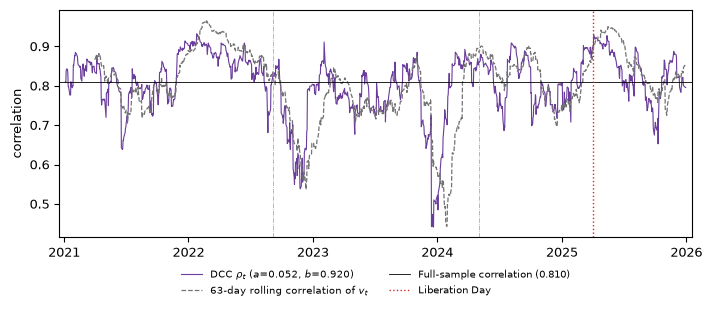

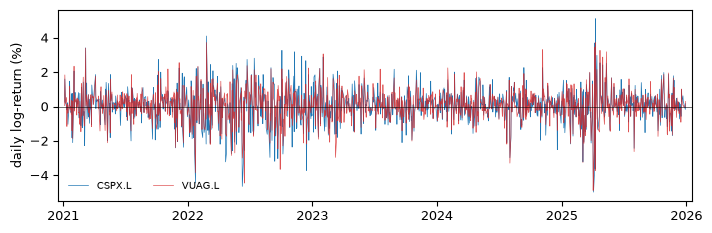

In [29]:
V = np.column_stack([results[a]["grid"][results[a]["best"]]["v"] for a in assets])
thirds = np.array_split(np.arange(T), 3)
periods = [("Full sample", np.arange(T))] + [(n, idx) for n, idx in
                                              zip(["First third", "Second third", "Last third"], thirds)]
lines = [r"\begin{tabular}{llrrrr}", r"\toprule",
         r"Period & Dates & $T$ & $\hat\rho(v_{1t}, v_{2t})$ & s.e. & $\hat\rho(y_{1t}, y_{2t})$ \\", r"\midrule"]
corr_rows = []
for name, idx in periods:
    rho = np.corrcoef(V[idx].T)[0, 1]
    rho_y = returns.iloc[idx].corr().iloc[0, 1]
    se = (1 - rho**2) / np.sqrt(len(idx))
    corr_rows.append((name, rho, len(idx)))
    lines.append(f"{name} & {dates[idx[0]]:%Y-%m-%d} -- {dates[idx[-1]]:%Y-%m-%d} & {len(idx)} & "
                 f"{fmt(rho)} & {fmt(se)} & {fmt(rho_y)}" + r" \\")
# Fisher z test of equal correlations over the three thirds
z = np.array([np.arctanh(r) for _, r, _ in corr_rows[1:]])
n = np.array([n for _, _, n in corr_rows[1:]])
zbar = (z * (n - 3)).sum() / (n - 3).sum()
chi = ((n - 3) * (z - zbar) ** 2).sum()
p_eq = stats.chi2.sf(chi, 2)
lines += [r"\midrule", rf"\multicolumn{{6}}{{l}}{{Test of equal correlation in the three thirds: "
                       rf"$\chi^2_2 = {chi:.1f}$, $p$ = {fmt_p(p_eq)}}} \\",
          r"\bottomrule", r"\end{tabular}"]
write("tab_corr.tex", "\n".join(lines))
print("\ncorrelation thirds", [(n, round(r, 4)) for n, r, _ in corr_rows], f"chi2={chi:.2f} p={p_eq:.4g}")

dcc = fit_dcc(V)
a_, b_ = dcc["theta"]
lr = 2 * (dcc["loglik"] - dcc["ll_const"])
# under H0 (a = 0) b is not identified and a lies on the boundary; the chi2(2) p-value is only indicative
lines = [r"\begin{tabular}{lrr}", r"\toprule", r" & Estimate & Robust s.e.\ (s.e.) \\", r"\midrule",
         rf"$a$ & {fmt(a_, 4)} & {fmt(dcc['se_rob'][0], 4)} ({fmt(dcc['se'][0], 4)}) \\",
         rf"$b$ & {fmt(b_, 4)} & {fmt(dcc['se_rob'][1], 4)} ({fmt(dcc['se'][1], 4)}) \\",
         rf"$a+b$ & {fmt(a_ + b_, 4)} & \\", r"\midrule",
         rf"$\log L$, DCC & {fmt(dcc['loglik'], 2)} & \\",
         rf"$\log L$, constant correlation ($\hat\rho = {dcc['rho_const']:.3f}$) & {fmt(dcc['ll_const'], 2)} & \\",
         rf"LR statistic & {fmt(lr, 2)} & \\",
         rf"Range of $\rho_t$ & {fmt(dcc['rho'].min())} -- {fmt(dcc['rho'].max())} & \\",
         r"\bottomrule", r"\end{tabular}"]
write("tab_dcc.tex", "\n".join(lines))
rho = pd.Series(dcc["rho"], index=dates)
print(f"DCC a={a_:.4f} ({dcc['se_rob'][0]:.4f}) b={b_:.4f} ({dcc['se_rob'][1]:.4f}) "
      f"ll={dcc['loglik']:.2f} ll_const={dcc['ll_const']:.2f} LR={lr:.2f}")
print("rho_t around Liberation Day\n", rho.loc["2025-03-27":"2025-04-25"].round(3).to_string())
print("lowest rho_t\n", rho.nsmallest(8).round(3).to_string())
print("highest rho_t\n", rho.nlargest(5).round(3).to_string())

rolling = pd.DataFrame(V, index=dates).rolling(63).corr().xs(0, level=1)[1]
fig, ax = plt.subplots(figsize=(7.2, 3.2))
ax.plot(dates, rho, color="#6a3d9a", lw=0.8, label=rf"DCC $\rho_t$ ($a$={a_:.3f}, $b$={b_:.3f})")
ax.plot(dates, rolling, color="0.45", lw=0.9, ls="--", label="63-day rolling correlation of $v_t$")
ax.axhline(dcc["rho_const"], color="k", lw=0.6, label=f"Full-sample correlation ({dcc['rho_const']:.3f})")
for idx in thirds[1:]:
    ax.axvline(dates[idx[0]], color="0.6", lw=0.5, ls="-.")
ax.axvline(LIBERATION_DAY, color="#d62728", ls=":", lw=1, label="Liberation Day")
ax.set_ylabel("correlation")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), frameon=False, ncol=2)
ax.margins(x=0.01)
fig.tight_layout()
fig.savefig(os.path.join(OUT, "fig_dcc.pdf"))
plt.show()

fig, ax = plt.subplots(figsize=(7.2, 2.4))
ax.plot(dates, returns.iloc[:, 0], lw=0.5, color=COLORS["GARCH"], label=assets[0])
ax.plot(dates, returns.iloc[:, 1], lw=0.5, color=COLORS["GJR"], alpha=0.8, label=assets[1])
ax.axhline(0, color="k", lw=0.4)
ax.set_ylabel("daily log-return (%)")
ax.legend(loc="lower left", frameon=False, ncol=2)
ax.margins(x=0.01)
fig.tight_layout()
fig.savefig(os.path.join(OUT, "fig_returns.pdf"))
plt.show()